# 准备工作

首先，我们导入必要的库，并设置 CUDA 设备.  
为避免 notebook 过于臃肿，我将工具函数放在了 `my_utils.py` 文件中，将模型定义放在了 `my_model.py` 文件中.

In [ ]:
# Import required libraries
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import torch
import torch.nn as nn
from torch import optim

import torchvision
show = torchvision.transforms.ToPILImage()

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import concurrent.futures as cf
import multiprocessing as mp
import itertools

# Import custom utilities and model definitions
from my_utils import (
    CIFAR_10_MEAN,
    CIFAR_10_STD,
    CIFAR_10_CLASS,
    FIGURE_DIR,
    get_device,
    get_cifar10_data_augmentation,
    train_model,
    train_experiment,
    evaluate,
    plot_loss_curves,
    plot_task3_hyperparameter_effects,
    count_parameters,
    create_learning_rate_scheduler
)
from my_model import (
    LeNet,
    MyCNN
)

接下来，我们下载 CIFAR-10 数据集，并进行训练集和验证集的划分.

In [ ]:
# Set image normalization transforms and download the dataset
os.makedirs('./dataset', exist_ok=True)

# Get light augmentation for LeNet baseline (only flips + crops).
transform_train_light, transform_test = get_cifar10_data_augmentation(style='light')

# Get full augmentation for modern CNN (Task4) — stored here for later use.
transform_train_full, _ = get_cifar10_data_augmentation(style='full')

# Set batch size
BATCH_SIZE = 64

# Load CIFAR-10 with light augmentation for training
full_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_light
)

# Load CIFAR-10 WITHOUT augmentation for validation (clean metrics for early stopping)
full_trainset_clean = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_test
)

# Split into train/val with consistent indices (same split for both datasets)
val_size = int(0.1 * len(full_trainset))
torch.manual_seed(51)
indices = torch.randperm(len(full_trainset)).tolist()
train_indices = indices[val_size:]
val_indices = indices[:val_size]

trainset = torch.utils.data.Subset(full_trainset, train_indices)
valset = torch.utils.data.Subset(full_trainset_clean, val_indices)

print(f"Train set size: {len(trainset)}, Validation set size: {len(valset)}")

# Test set
testset = torchvision.datasets.CIFAR10(
    root='./dataset', train=False, download=True, transform=transform_test
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    valset, batch_size=BATCH_SIZE*8, shuffle=False, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE*8, shuffle=False, num_workers=2
)

Train set size: 45000, Validation set size: 5000


经检验，CIFAR-10 的每个类别都有 $5000$ 张图像，因此其类别分布是平衡的.

CIFAR-10 Dataset Statistics
Full training set:  50000 images
  - Training split: 45000 images
  - Validation split: 5000 images
Test set:           10000 images
Image dimensions:   torch.Size([3, 32, 32])
Number of CIFAR_10_CLASS:  10

Class Distribution:
----------------------------------------
  0: plane      5000 images (10.0%)
  1: car        5000 images (10.0%)
  2: bird       5000 images (10.0%)
  3: cat        5000 images (10.0%)
  4: deer       5000 images (10.0%)
  5: dog        5000 images (10.0%)
  6: frog       5000 images (10.0%)
  7: horse      5000 images (10.0%)
  8: ship       5000 images (10.0%)
  9: truck      5000 images (10.0%)


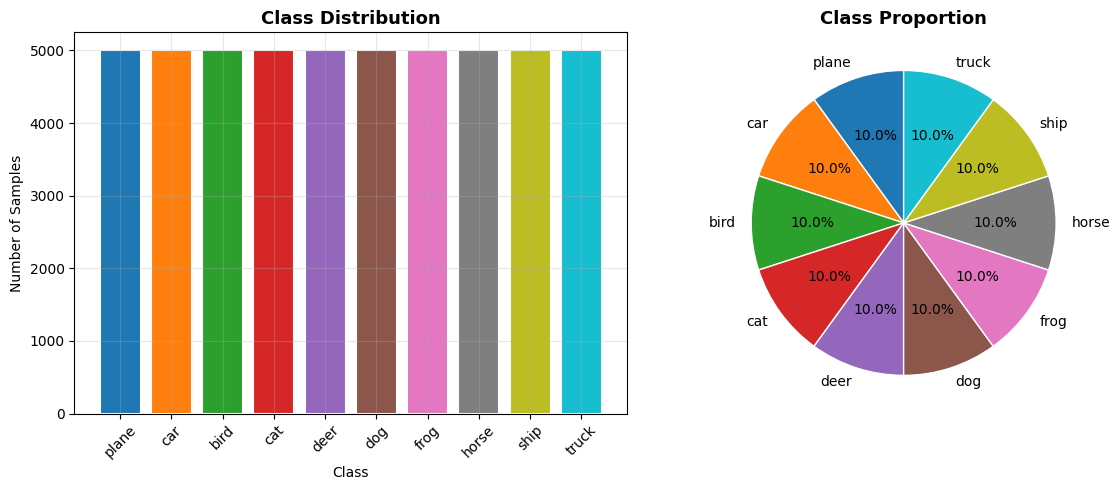

In [3]:
# Data Exploration: Class Distribution and Dataset Statistics
save_path = FIGURE_DIR / 'data_exploration_class_distribution.pdf'

# Collect labels from the full training set
train_labels = [full_trainset[i][1] for i in range(len(full_trainset))]
class_counts = [train_labels.count(i) for i in range(10)]

print("=" * 60)
print("CIFAR-10 Dataset Statistics")
print("=" * 60)
print(f"Full training set:  {len(full_trainset):>5} images")
print(f"  - Training split: {len(trainset):>5} images")
print(f"  - Validation split:{len(valset):>5} images")
print(f"Test set:           {len(testset):>5} images")
print(f"Image dimensions:   {full_trainset[0][0].shape}")
print(f"Number of CIFAR_10_CLASS:  {len(CIFAR_10_CLASS)}")
print()
print("Class Distribution:")
print("-" * 40)
for i, (cls, count) in enumerate(zip(CIFAR_10_CLASS, class_counts)):
    print(f"  {i}: {cls:<8s}  {count:>5} images ({100 * count / len(full_trainset):.1f}%)")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.arange(10))

ax1.bar(CIFAR_10_CLASS, class_counts, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.pie(class_counts, labels=CIFAR_10_CLASS, autopct='%1.1f%%', colors=colors,
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax2.set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

下面的代码将展示 CIFAR-10 数据集中每个类别的样本图像.

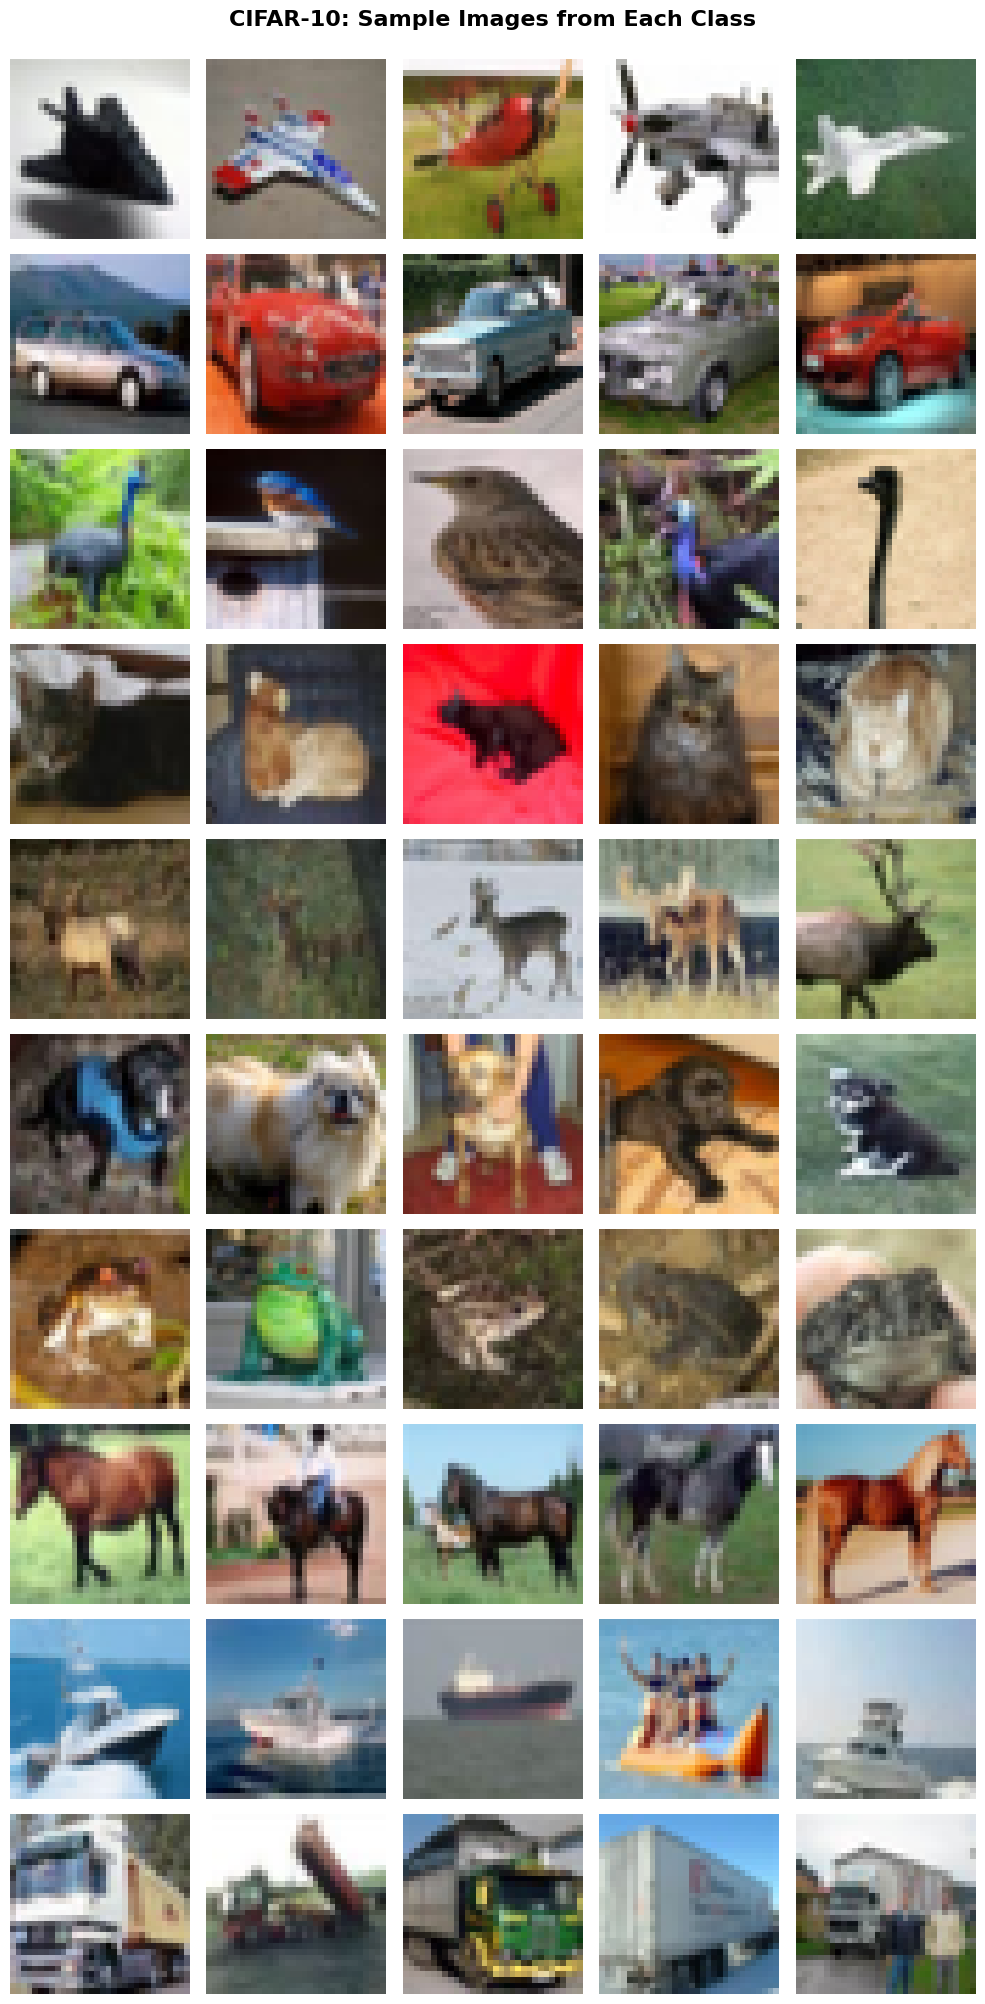

In [4]:
# Data Exploration: Sample Grid from Each Class
save_path = FIGURE_DIR / 'data_exploration_sample_grid.pdf'
samples_per_class = 5

# Load raw training set (without augmentation for clean display)
raw_trainset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR_10_MEAN, CIFAR_10_STD)
    ])
)

# Collect images per class
class_samples = {i: [] for i in range(10)}
for img, label in raw_trainset:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) >= samples_per_class for v in class_samples.values()):
        break

# Plot grid: 10 rows (CIFAR_10_CLASS) x 5 columns (samples)
fig, axes = plt.subplots(10, samples_per_class, figsize=(samples_per_class * 2, 20))
fig.suptitle('CIFAR-10: Sample Images from Each Class', fontsize=16, fontweight='bold', y=1)

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

for i in range(10):
    for j in range(samples_per_class):
        img = class_samples[i][j]
        img_display = img * std_t + mean_t  # Denormalize
        axes[i, j].imshow(img_display.permute(1, 2, 0).clamp(0, 1).numpy())
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(CIFAR_10_CLASS[i], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

接下来，我们计算每个通道的统计信息，观察其分布.

Per-Channel Pixel Statistics (raw [0, 1] range)
   Red | Mean: 0.4914 | Std: 0.2470 | Min: 0.0000 | Max: 1.0000
 Green | Mean: 0.4822 | Std: 0.2435 | Min: 0.0000 | Max: 1.0000
  Blue | Mean: 0.4465 | Std: 0.2616 | Min: 0.0000 | Max: 1.0000

Overall   | Mean: 0.4734 | Std: 0.2516


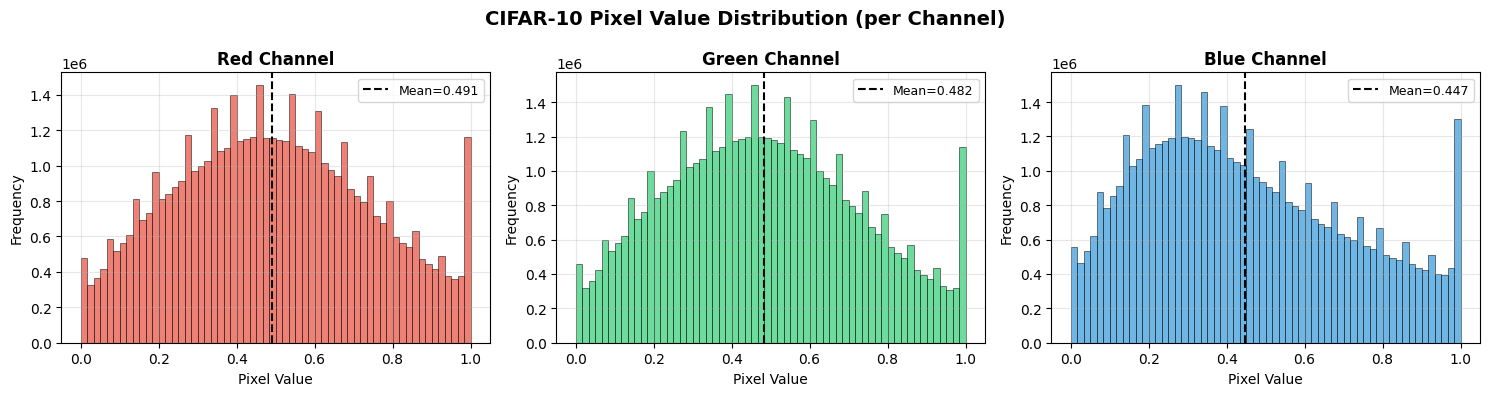

In [5]:
# Data Exploration: Per-Channel Pixel Statistics and Histograms
save_path = FIGURE_DIR / 'data_exploration_pixel_histograms.pdf'
raw_trainset_stats = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False,
    transform=torchvision.transforms.ToTensor()
)

# Stack images
all_pixels = np.stack([np.asarray(raw_trainset_stats[i][0]) for i in range(len(raw_trainset_stats))])

print("=" * 70)
print("Per-Channel Pixel Statistics (raw [0, 1] range)")
print("=" * 70)
channels = ['Red', 'Green', 'Blue']
for i, ch_name in enumerate(channels):
    ch = all_pixels[:, i, :, :]
    print(f"{ch_name:>6} | Mean: {ch.mean():.4f} | Std: {ch.std():.4f} | "
          f"Min: {ch.min():.4f} | Max: {ch.max():.4f}")

print()
print(f"Overall   | Mean: {all_pixels.mean():.4f} | Std: {all_pixels.std():.4f}")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_hist = ['#e74c3c', '#2ecc71', '#3498db']

for i, (ch_name, color) in enumerate(zip(channels, colors_hist)):
    ch_data = all_pixels[:, i, :, :].flatten()
    axes[i].hist(ch_data, bins=60, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].axvline(ch_data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={ch_data.mean():.3f}')
    axes[i].set_title(f'{ch_name} Channel', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('CIFAR-10 Pixel Value Distribution (per Channel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

最后，我们展示数据增强的效果，以指导数据增强策略的设计.

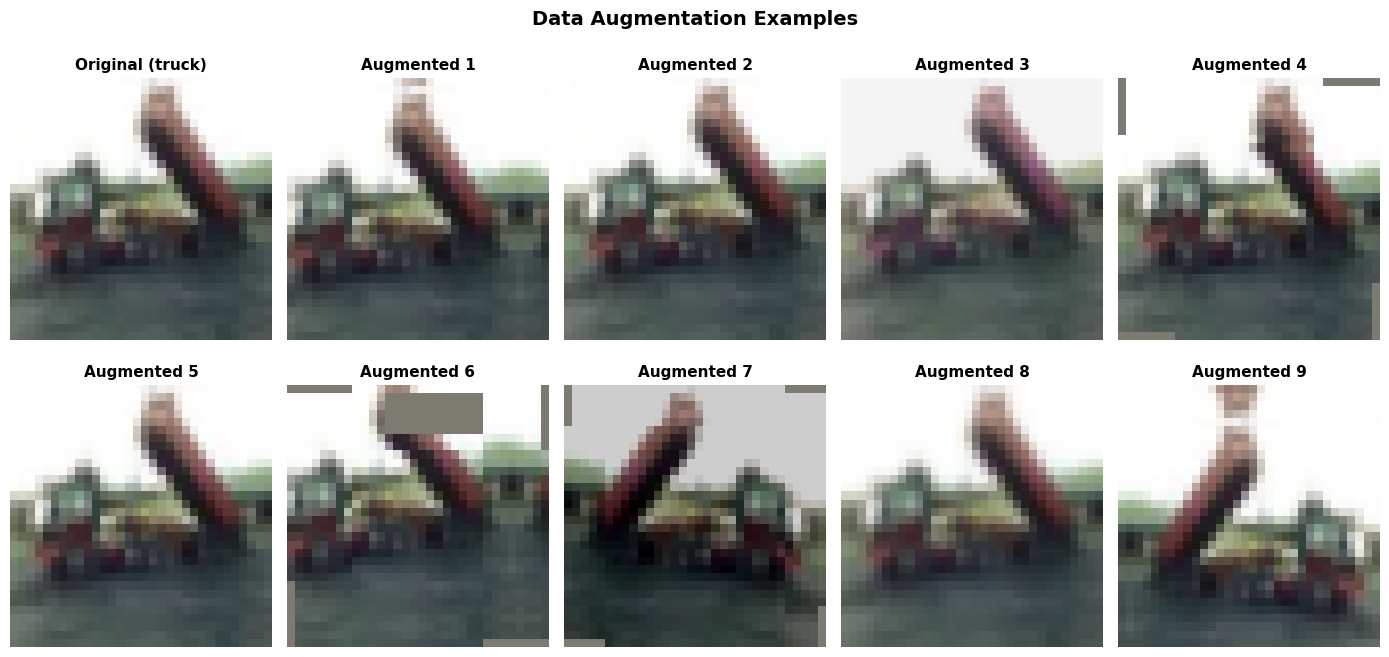

Augmentation visualization saved.
Class: truck


In [6]:
# Data Exploration: Data Augmentation Visualization
# Get a clean PIL image and its label
save_path = FIGURE_DIR / 'data_exploration_augmentation.pdf'
raw_pil_dataset = torchvision.datasets.CIFAR10(
    root='./dataset', 
    train=True, 
    download=False
)
sample_img, sample_label = raw_pil_dataset[2]

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
axes = axes.flatten()

mean_t = torch.tensor(CIFAR_10_MEAN).view(3, 1, 1)
std_t = torch.tensor(CIFAR_10_STD).view(3, 1, 1)

# Original image (no augmentation)
axes[0].imshow(np.array(sample_img))
axes[0].set_title(f'Original ({CIFAR_10_CLASS[sample_label]})', fontsize=11, fontweight='bold')
axes[0].axis('off')

# 9 augmented versions using transform_train_full (heavy augmentation for visualization)
for i in range(1, 10):
    aug = transform_train_full(sample_img)
    aug_display = aug * std_t + mean_t  # Denormalize
    axes[i].imshow(aug_display.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i].set_title(f'Augmented {i}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Augmentation visualization saved.\nClass: {CIFAR_10_CLASS[sample_label]}")

# Task1: LeNet Baseline

首先，我们定义 LeNet-5，并打印模型结构.

In [22]:
lenet_baseline = LeNet(dropout=None)
print(lenet_baseline)

param_counts = count_parameters(lenet_baseline)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Total parameters: 62.006K
Trainable parameters: 62.006K, Non-trainable parameters: 0


然后在 CIFAR-10 数据集上训练 LeNet-5 模型，并保存训练过程中的损失和验证集准确率.

In [23]:
# Set device (GPU if available)
device = get_device()
print(f"Using device: {device}")

# Move model to device
lenet_baseline = lenet_baseline.to(device)

# --- Shared hyperparameters (used across baseline experiment and Task 2) ---
LR = 5e-3
MIN_LR = LR * 0.01
MOMENTUM = 0.9
NUM_EPOCHS = 64
EARLY_STOPPING_PATIENCE = 16
T_0 = 48
T_MULT = 1
CYCLE_DECAY = 0.05

# --- Baseline experiment ---
LABEL_SMOOTHING = 0.0  # Will be adjusted in Task3

criterion_baseline = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

weight_decay_baseline = 0.0  # No L2 regularization; will be adjusted in Task2
optimizer_baseline = optim.SGD(
    lenet_baseline.parameters(), 
    lr=LR, 
    momentum=MOMENTUM, 
    weight_decay=weight_decay_baseline,
    nesterov=True
)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_baseline})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping patience={EARLY_STOPPING_PATIENCE})")

# Create learning rate scheduler config (linear warm-up + cosine annealing with restarts)
scheduler_config_baseline = create_learning_rate_scheduler(
    optimizer_baseline, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS, 
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0,
    T_mult=T_MULT,
    cycle_decay=CYCLE_DECAY
)

# Train the network
save_path_baseline = 'checkpoints/lenet_baseline'
train_losses_baseline, val_accuracies_baseline = train_model(
    model=lenet_baseline,
    train_loader=train_loader,
    criterion=criterion_baseline,
    optimizer=optimizer_baseline,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_baseline,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_baseline
)

Using GPU: NVIDIA GeForce RTX 4090
Using device: cuda:0
Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.005, momentum=0.9, weight_decay=0.0)
Epochs: 64 (with early stopping patience=16)
Created CosineAnnealingWarmRestartsDecay (T_0=48, T_mult=1, cycle_decay=0.05)
  Warm-up: 5 epoch(s), Initial LR: 0.005
  Min LR: 5e-05, Total epochs: 64
Training on device: cuda:0
Initial training loss (before training): 2.3015
Initial validation accuracy (before training): 8.36%
--------------------------------------------------
Epoch 1/64: Train Loss: 2.2820, Val Accuracy: 18.48%, Learning Rate: 0.001000, Grad Norm: 0.3320
  -> New best model saved with accuracy: 18.48%
Epoch 2/64: Train Loss: 1.9713, Val Accuracy: 36.44%, Learning Rate: 0.002000, Grad Norm: 2.0210
  -> New best model saved with accuracy: 36.44%
Epoch 3/64: Train Loss: 1.6705, Val Accuracy: 41.80%, Learning Rate: 0.003000, Grad Norm: 3.5361
  -> New best model saved with accuracy: 41.80%
Epoch 4/64: Train Lo

训练结束后，我们将在测试集上评估 LeNet-5 模型的性能，并打印出一些关键指标.

In [24]:
# Evaluate on test set
print("\nEvaluating LeNet baseline on test set...")
test_result_baseline = evaluate(
    model=lenet_baseline, test_loader=test_loader, device=device,
    model_name='lenet_baseline', save_plots=True,
)
test_accuracy_baseline = test_result_baseline['accuracy']

# Results comparison
print("\n=== Baseline Results ===")
print(f"  - Best validation accuracy:   {max(val_accuracies_baseline):.2f}%")
print(f"  - Final validation accuracy:  {val_accuracies_baseline[-1]:.2f}%")
print(f"  - Test accuracy:              {test_accuracy_baseline:.2f}%")
print(f"  - ECE (calibration error):    {test_result_baseline['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_baseline['pred_dist_kl']:.6f}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_baseline['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")


Evaluating LeNet baseline on test set...

=== Baseline Results ===
  - Best validation accuracy:   67.22%
  - Final validation accuracy:  66.90%
  - Test accuracy:              68.02%
  - ECE (calibration error):    0.0302
  - Pred distribution KL:       0.002131
  - Best F1:      ship = 0.8014
  - Worst F1:      cat = 0.4824


最后，我们绘制损失曲线，并清理 GPU 内存.

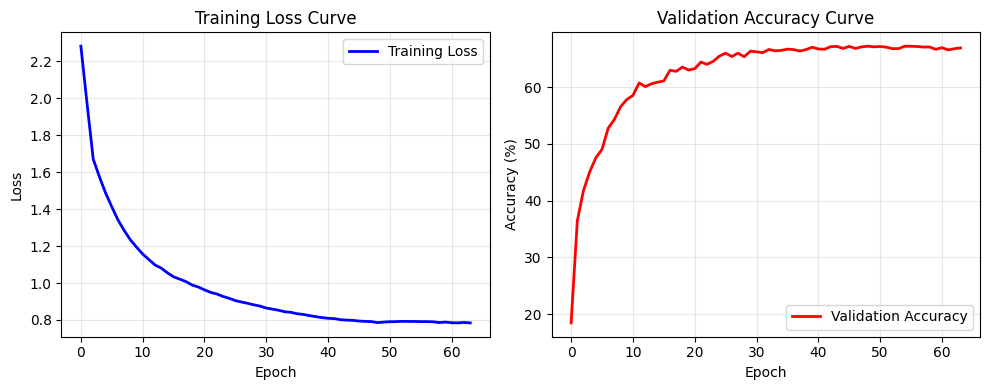

Loss curve saved to figures/lenet_baseline_loss_curve.pdf
Final training loss: 0.7843
Final validation accuracy: 66.90%


In [25]:
# Plot loss curves using utility function
plot_loss_curves(train_losses_baseline, val_accuracies_baseline, FIGURE_DIR / 'lenet_baseline_loss_curve.pdf')

In [26]:
# Clean up GPU memory
del lenet_baseline, optimizer_baseline, criterion_baseline, scheduler_config_baseline
del train_losses_baseline, val_accuracies_baseline
torch.cuda.empty_cache()

# Task2: LeNet + Regularization

首先，我们在 LeNet-5 中引入 Dropout 层 (位于前两个全连接层之间)，并打印模型结构.

In [12]:
# Instantiate LeNet with dropout for Task3 experiments
lenet_dropout = LeNet(dropout=0.1)
print(lenet_dropout)

param_counts = count_parameters(lenet_dropout)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 62.006K
Trainable parameters: 62.006K, Non-trainable parameters: 0


同时，我们在损失函数中引入了 L2 正则项.  
然后在 CIFAR-10 数据集上训练引入了 Dropout 层的 LeNet-5 模型，并绘制了损失函数曲线.

Loss function: CrossEntropyLoss (label_smoothing=0.0)
Optimizer: SGD (lr=0.005, momentum=0.9, weight_decay=0.0001)
Epochs: 64 (with early stopping patience=16)
Created CosineAnnealingWarmRestartsDecay (T_0=48, T_mult=1, cycle_decay=0.05)
  Warm-up: 5 epoch(s), Initial LR: 0.005
  Min LR: 5e-05, Total epochs: 64
Training on device: cuda:0
Initial training loss (before training): 2.3107
Initial validation accuracy (before training): 10.28%
--------------------------------------------------
Epoch 1/64: Train Loss: 2.2918, Val Accuracy: 14.42%, Learning Rate: 0.001000, Grad Norm: 0.2429
  -> New best model saved with accuracy: 14.42%
Epoch 2/64: Train Loss: 2.0081, Val Accuracy: 33.84%, Learning Rate: 0.002000, Grad Norm: 1.6274
  -> New best model saved with accuracy: 33.84%
Epoch 3/64: Train Loss: 1.7580, Val Accuracy: 39.88%, Learning Rate: 0.003000, Grad Norm: 2.7167
  -> New best model saved with accuracy: 39.88%
Epoch 4/64: Train Loss: 1.6250, Val Accuracy: 42.18%, Learning Rate: 0.0

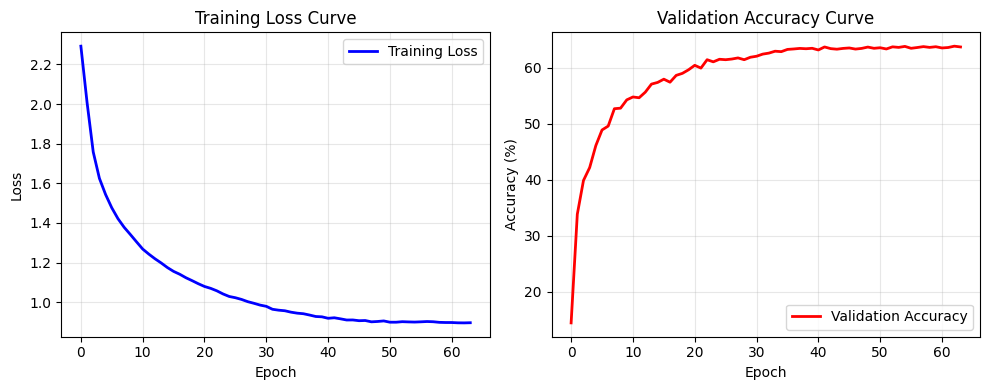

Loss curve saved to figures/lenet_dropout_loss_curve.pdf
Final training loss: 0.8968
Final validation accuracy: 63.74%


In [13]:
# Task2: Train model with Dropout + L2 regularization
# Move model to device
lenet_dropout = lenet_dropout.to(device)

# Dropout experiment: L2 regularization via weight_decay
weight_decay_dropout = 1e-4
optimizer_dropout = optim.SGD(
    lenet_dropout.parameters(), 
    lr=LR, 
    momentum=MOMENTUM, 
    weight_decay=weight_decay_dropout,
    nesterov=True
)
criterion_dropout = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={weight_decay_dropout})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping patience={EARLY_STOPPING_PATIENCE})")

# Create learning rate scheduler config (separate instance for this optimizer)
scheduler_config_dropout = create_learning_rate_scheduler(
    optimizer_dropout, 
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0,
    T_mult=T_MULT,
    cycle_decay=CYCLE_DECAY
)

# Train Dropout network with L2 regularization
save_path_dropout = 'checkpoints/lenet_dropout'
train_losses_dropout, val_accuracies_dropout = train_model(
    model=lenet_dropout,
    train_loader=train_loader,
    criterion=criterion_dropout,
    optimizer=optimizer_dropout,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_dropout,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_dropout
)

# Plot loss curves
plot_loss_curves(train_losses_dropout, val_accuracies_dropout, FIGURE_DIR / 'lenet_dropout_loss_curve.pdf')

训练结束后，我们将在测试集上评估 LeNet-5 模型的性能，并打印出一些关键指标.

In [14]:
# Evaluate on test set
print("\nEvaluating LeNet with Dropout on test set...")
test_result_dropout = evaluate(
    model=lenet_dropout, 
    test_loader=test_loader, 
    device=device,
    model_name='lenet_dropout', 
    save_plots=True
)
test_accuracy_dropout = test_result_dropout['accuracy']

# Results comparison
print("\n=== Task2 Results: Dropout + L2 Regularization ===")
print(f"  - Best validation accuracy:   {max(val_accuracies_dropout):.2f}%")
print(f"  - Final validation accuracy:  {val_accuracies_dropout[-1]:.2f}%")
print(f"  - Test accuracy:              {test_accuracy_dropout:.2f}%")
print(f"  - ECE (calibration error):    {test_result_dropout['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_dropout['pred_dist_kl']:.6f}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_dropout['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")

# MC Dropout uncertainty (LeNet with dropout enables this)
if test_result_dropout.get('mc_dropout'):
    md = test_result_dropout['mc_dropout']
    print(f"\nMC Dropout Uncertainty:")
    print(f"  - Avg predictive variance:       {md['variance_mean']:.6f}")
    print(f"  - Accurate variance (mean):      {md.get('accurate_var_mean', 'N/A')}")
    print(f"  - Inaccurate variance (mean):    {md.get('inaccurate_var_mean', 'N/A')}")


Evaluating LeNet with Dropout on test set...

=== Task2 Results: Dropout + L2 Regularization ===
  - Best validation accuracy:   63.88%
  - Final validation accuracy:  63.74%
  - Test accuracy:              65.01%
  - ECE (calibration error):    0.0194
  - Pred distribution KL:       0.002152
  - Best F1:      ship = 0.7724
  - Worst F1:      cat = 0.4726

MC Dropout Uncertainty:
  - Avg predictive variance:       0.010727
  - Accurate variance (mean):      0.009865955449640751
  - Inaccurate variance (mean):    0.01232318114489317


最后，我们清理 GPU 内存.

In [15]:
# Clean up GPU memory
del lenet_dropout, optimizer_dropout, criterion_dropout, scheduler_config_dropout
del train_losses_dropout, val_accuracies_dropout
torch.cuda.empty_cache()

# Task3: Hyperparameter Tuning Experiments

我们将使用 LeNet-5 作为基线模型，并调整以下四个超参数:

- 学习率 (learning rate, lr)
- 权重衰减 (weight decay, wd)
- 标签平滑 (label smoothing, ls)
- 批量大小 (batch size, bs)

我们将使用 $3\times 3 \times 2 \times 3$ 的网格搜索，总共 $54$ 个实验，并使用 $10$ 个并发工作进程并行执行这些实验.

In [16]:
# Task3: Hyperparameter Tuning Experiments (3x3x2x3 grid, 54 experiments)
# Parallel execution with MAX_WORKERS concurrent worker processes.
MAX_WORKERS = 10
DROPOUT = None
NUM_EPOCHS = 64
EARLY_STOPPING_PATIENCE = 16
MOMENTUM = 0.9
T_0 = 48
T_MULT = 1
CYCLE_DECAY = 0.05

# Hyperparameter grid
LR_GRID = [1e-3, 5e-3, 1e-2]
WD_GRID = [0, 1e-4, 1e-3]
LS_GRID = [0, 1e-1]
BS_GRID = [4, 16, 64]
# All Task3 experiments use LeNet for consistent comparison
NUM_EXPERIMENTS = len(LR_GRID) * len(WD_GRID) * len(LS_GRID) * len(BS_GRID)

print("=" * 70)
print("Task3: Hyperparameter Tuning Experiments (Parallel, LeNet)")
print(f"  lr           = {LR_GRID}")
print(f"  weight_decay = {WD_GRID}")
print(f"  label_smooth = {LS_GRID}")
print(f"  batch_size   = {BS_GRID}")
print(f"  Total: {NUM_EXPERIMENTS} experiments x {NUM_EPOCHS} epochs each")
print(f"  Workers: {MAX_WORKERS} concurrent on GPU")
print("=" * 70)

# Create output directories
LOG_DIR = Path('logs/task3')
LOG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path('checkpoints/task3')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Prepare argument list for all experiments.
# train_indices / val_indices are the lists from the data-prep cell above.
experiment_args = []
for exp_idx, (lr, wd, ls, bs) in enumerate(
    itertools.product(LR_GRID, WD_GRID, LS_GRID, BS_GRID), 1
):
    min_lr = lr * 0.01  # Minimum LR for scheduler
    experiment_args.append((
        exp_idx, DROPOUT, lr, wd, ls, bs,
        train_indices, val_indices,
        NUM_EPOCHS, min_lr, T_0, T_MULT, CYCLE_DECAY, MOMENTUM,
        str(CKPT_DIR), str(LOG_DIR)
    ))

results = []

# Use spawn context for safe CUDA multiprocessing
ctx = mp.get_context('spawn')

print(f"\nStarting parallel execution with {MAX_WORKERS} workers...")
print(f"Multiprocessing context: {ctx.get_start_method()}\n")

with cf.ProcessPoolExecutor(max_workers=MAX_WORKERS, mp_context=ctx) as executor:
    # Submit all experiments to the pool
    future_map = {
        executor.submit(train_experiment, *args): args
        for args in experiment_args
    }

    # Collect results as they complete
    for future in cf.as_completed(future_map):
        args = future_map[future]
        exp_idx = args[0]
        try:
            result = future.result()
            results.append(result)
            print(f"[{result['experiment_id']:02d}/{NUM_EXPERIMENTS}] "
                  f"lr={result['learning_rate']}, wd={result['weight_decay']}, "
                  f"ls={result['label_smoothing']}, bs={result['batch_size']} | "
                  f"val_acc={result['best_val_accuracy']:.2f}%, "
                  f"test_acc={result['test_accuracy']:.2f}%, "
                  f"epochs={result['epochs_trained']}")
        except Exception as e:
            print(f"[{exp_idx:02d}/{NUM_EXPERIMENTS}] FAILED: {e}")

# Sort by experiment_id for consistent ordering
results.sort(key=lambda r: r['experiment_id'])

Task3: Hyperparameter Tuning Experiments (Parallel, LeNet)
  lr           = [0.001, 0.005, 0.01]
  weight_decay = [0, 0.0001, 0.001]
  label_smooth = [0, 0.1]
  batch_size   = [4, 16, 64]
  Total: 54 experiments x 64 epochs each
  Workers: 10 concurrent on GPU

Starting parallel execution with 10 workers...
Multiprocessing context: spawn



terminate called without an active exception


[03/54] lr=0.001, wd=0, ls=0, bs=64 | val_acc=54.70%, test_acc=54.17%, epochs=54
[09/54] lr=0.001, wd=0.0001, ls=0, bs=64 | val_acc=53.40%, test_acc=52.42%, epochs=55
[06/54] lr=0.001, wd=0, ls=0.1, bs=64 | val_acc=54.86%, test_acc=54.79%, epochs=55
[05/54] lr=0.001, wd=0, ls=0.1, bs=16 | val_acc=61.22%, test_acc=61.46%, epochs=53
[08/54] lr=0.001, wd=0.0001, ls=0, bs=16 | val_acc=61.08%, test_acc=60.97%, epochs=64
[02/54] lr=0.001, wd=0, ls=0, bs=16 | val_acc=57.84%, test_acc=58.03%, epochs=64
[12/54] lr=0.001, wd=0.0001, ls=0.1, bs=64 | val_acc=55.04%, test_acc=54.96%, epochs=56
[15/54] lr=0.001, wd=0.001, ls=0, bs=64 | val_acc=53.94%, test_acc=54.12%, epochs=52
[11/54] lr=0.001, wd=0.0001, ls=0.1, bs=16 | val_acc=61.28%, test_acc=60.10%, epochs=64
[14/54] lr=0.001, wd=0.001, ls=0, bs=16 | val_acc=58.26%, test_acc=57.89%, epochs=64
[01/54] lr=0.001, wd=0, ls=0, bs=4 | val_acc=63.78%, test_acc=64.08%, epochs=55
[07/54] lr=0.001, wd=0.0001, ls=0, bs=4 | val_acc=65.56%, test_acc=64.43%,

下面的代码将展示所有实验结果的汇总 (按测试集准确率排序) 并保存到 CSV 文件中.


Hyperparameter Tuning Results (sorted by test_accuracy):
 experiment_id  learning_rate  weight_decay  label_smoothing  batch_size  best_val_accuracy  test_accuracy  final_train_loss  epochs_trained optimizer                                          log_file
            53          0.010        0.0010              0.1          16              71.54          71.40          1.056738              62      Adam   logs/task3/exp_53_lr0.01_wd0.001_ls0.1_bs16.log
            50          0.010        0.0010              0.0          16              71.38          70.96          0.701791              59      Adam     logs/task3/exp_50_lr0.01_wd0.001_ls0_bs16.log
            28          0.005        0.0001              0.1           4              71.30          70.93          0.878553              52      Adam  logs/task3/exp_28_lr0.005_wd0.0001_ls0.1_bs4.log
            43          0.010        0.0001              0.0           4              70.70          70.84          0.437932              

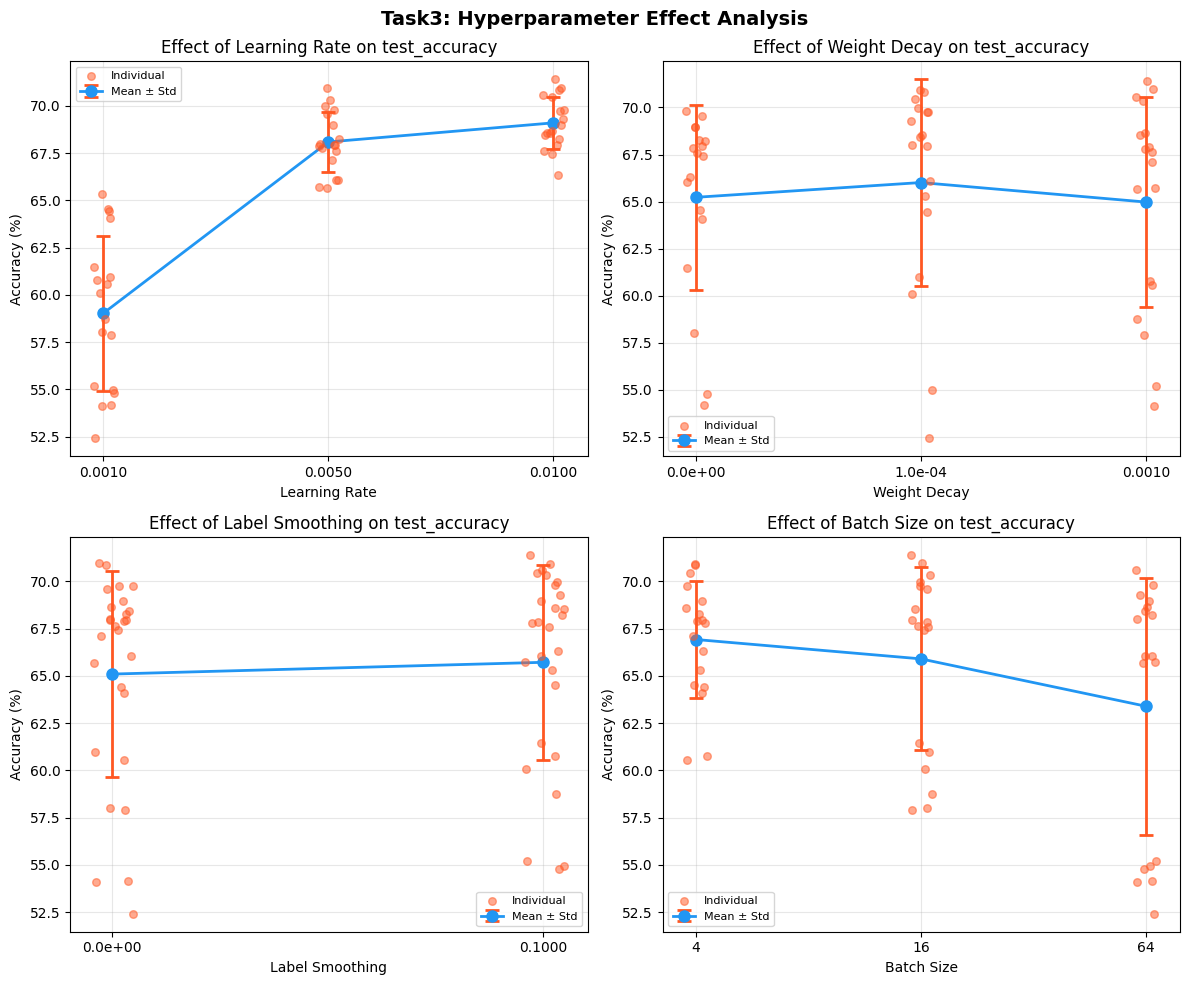

Saved: figures/task3_hyperparameter_effects.pdf


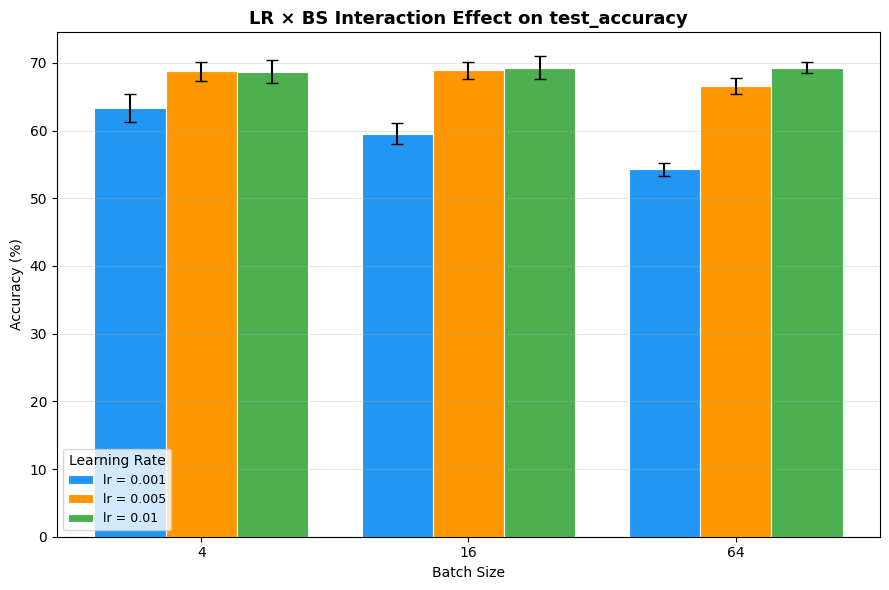

Saved: figures/task3_lr_bs_interaction.pdf

Best Hyperparameter Combination (by test accuracy):
  experiment_id: 53
  learning_rate: 0.01
  weight_decay: 0.001
  label_smoothing: 0.1
  batch_size: 16
  best_val_accuracy: 71.54
  test_accuracy: 71.39999999999999
  final_train_loss: 1.0567384930085848
  epochs_trained: 62
  optimizer: Adam
  log_file: logs/task3/exp_53_lr0.01_wd0.001_ls0.1_bs16.log


In [17]:
# --- Results summary ---
results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Hyperparameter Tuning Results (sorted by test_accuracy):")
print("=" * 70)
print(results_df.sort_values('test_accuracy', ascending=False).to_string(index=False))

# Save to CSV
results_df.to_csv('task3_hyperparameter_results.csv', index=False)
print(f"\nResults saved to 'task3_hyperparameter_results.csv'")
print(f"Full logs saved to {LOG_DIR}/")

# --- Comprehensive Visualization ---
# Line charts showing systematic effect of each hyperparameter on test accuracy
plot_task3_hyperparameter_effects(
    results_df,
    save_dir='figures',
    figure_prefix='task3',
    metric='test_accuracy',
)

# --- Best combination (by test_accuracy) ---
best = results_df.loc[results_df['test_accuracy'].idxmax()]
print("\n" + "=" * 70)
print("Best Hyperparameter Combination (by test accuracy):")
print("=" * 70)
for col in results_df.columns:
    print(f"  {col}: {best[col]}")
print("=" * 70)

# Task4: Implement A Modern CNN

首先，我们实现了一个自定义的卷积神经网络 (`MyCNN`) 类，采用了 `ResNet` 式残差连接的结构.

In [18]:
# Instantiate MyCNN
mycnn = MyCNN(num_classes=len(CIFAR_10_CLASS), dropout=None)
print(mycnn)

param_counts = count_parameters(mycnn)
print(
    f"Total parameters: {param_counts['total']}\n"
    f"Trainable parameters: {param_counts['trainable']}, "
    f"Non-trainable parameters: {param_counts['non_trainable']}"
)

MyCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


接下来，我们在 CIFAR-10 数据集上训练这个自定义的卷积神经网络，并绘制损失函数曲线.

Using GPU: NVIDIA GeForce RTX 4090
Loss function: CrossEntropyLoss (label_smoothing=0.05)
Optimizer: SGD (lr=0.1, momentum=0.9, weight_decay=0.0005)
Epochs: 320 (with early stopping patience=64)
Created CosineAnnealingWarmRestartsDecay (T_0=80, T_mult=1, cycle_decay=0.1)
  Warm-up: 5 epoch(s), Initial LR: 0.1
  Min LR: 0.0001, Total epochs: 320
Training on device: cuda:0
Initial training loss (before training): 2.3019
Initial validation accuracy (before training): 8.80%
--------------------------------------------------
Epoch 1/320: Train Loss: 1.4923, Val Accuracy: 60.60%, Learning Rate: 0.020000, Grad Norm: 5.8266
  -> New best model saved with accuracy: 60.60%
Epoch 2/320: Train Loss: 1.1140, Val Accuracy: 70.60%, Learning Rate: 0.040000, Grad Norm: 4.6382
  -> New best model saved with accuracy: 70.60%
Epoch 3/320: Train Loss: 0.9637, Val Accuracy: 76.58%, Learning Rate: 0.060000, Grad Norm: 3.3546
  -> New best model saved with accuracy: 76.58%
Epoch 4/320: Train Loss: 0.8845, Val

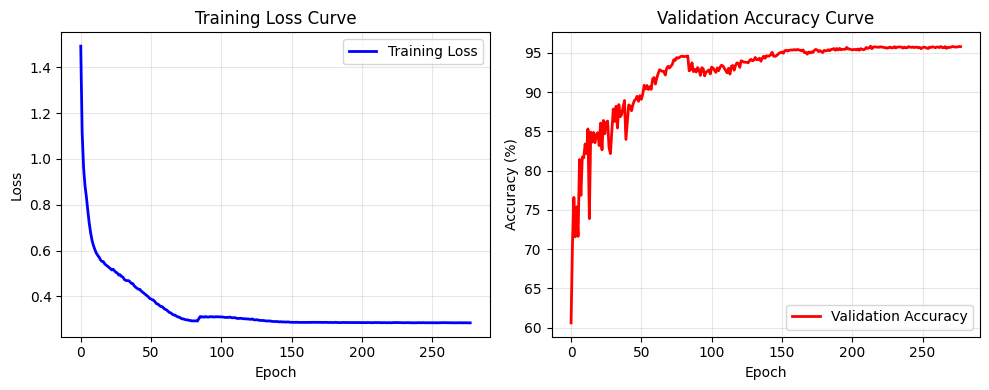

Loss curve saved to figures/mycnn_loss_curve.pdf
Final training loss: 0.2846
Final validation accuracy: 95.78%


In [19]:
# Task4: MyCNN
# Create DataLoader with full augmentation for modern CNN
BATCH_SIZE = 128
full_trainset_full_aug = torchvision.datasets.CIFAR10(
    root='./dataset', train=True, download=True, transform=transform_train_full
)
trainset_full_aug = torch.utils.data.Subset(full_trainset_full_aug, train_indices)
train_loader_full_aug = torch.utils.data.DataLoader(
    trainset_full_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    valset, batch_size=BATCH_SIZE*8, shuffle=False, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE*8, shuffle=False, num_workers=2
)

# Move model to device
device = get_device()
mycnn = mycnn.to(device)

# Configure optimizer and loss
LR = 1e-1
MIN_LR = LR * 1e-3
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 5e-2
NUM_EPOCHS = 320
EARLY_STOPPING_PATIENCE = 64
T_0 = 80
T_MULT = 1
CYCLE_DECAY = 1e-1

criterion_mycnn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer_mycnn = optim.SGD(
    mycnn.parameters(), 
    lr=LR, 
    weight_decay=WEIGHT_DECAY,
    momentum=MOMENTUM,
    nesterov=True
)

print(f"Loss function: CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer: SGD (lr={LR}, momentum={MOMENTUM}, weight_decay={WEIGHT_DECAY})")
print(f"Epochs: {NUM_EPOCHS} (with early stopping patience={EARLY_STOPPING_PATIENCE})")

# Create LR scheduler
scheduler_config_mycnn = create_learning_rate_scheduler(
    optimizer_mycnn,
    scheduler_type='cosine',
    total_epochs=NUM_EPOCHS,
    initial_lr=LR,
    min_lr=MIN_LR,
    T_0=T_0,
    T_mult=T_MULT,
    cycle_decay=CYCLE_DECAY
)

# Train
save_path_mycnn = 'checkpoints/mycnn'
train_losses_mycnn, val_accuracies_mycnn = train_model(
    model=mycnn,
    train_loader=train_loader_full_aug,
    criterion=criterion_mycnn,
    optimizer=optimizer_mycnn,
    num_epochs=NUM_EPOCHS,
    save_path=save_path_mycnn,
    val_loader=val_loader,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    scheduler_config=scheduler_config_mycnn
)

print(f"Final training loss: {train_losses_mycnn[-1]:.4f}")
if val_accuracies_mycnn:
    print(f"Final validation accuracy: {val_accuracies_mycnn[-1]:.2f}%")

# Plot loss curves
plot_loss_curves(train_losses_mycnn, val_accuracies_mycnn, FIGURE_DIR / 'mycnn_loss_curve.pdf')

训练结束后，我们将在测试集上评估 MyCNN 模型的性能，并打印出一些关键指标.

In [20]:
# Evaluate on test set
print("\nEvaluating MyCNN on test set...")
test_result_mycnn = evaluate(
    model=mycnn, 
    test_loader=test_loader, 
    device=device,
    model_name='mycnn', 
    save_plots=True
)
test_accuracy_mycnn = test_result_mycnn['accuracy']

# Safely retrieve training history (may vary across runs)
best_val_acc = max(val_accuracies_mycnn)
final_val_acc = val_accuracies_mycnn[-1]
epochs_done = len(train_losses_mycnn)

# Comparison with baseline model
print("\n" + "="*70)
print("Task4 Results:")
print("="*70)
print("MyCNN:")
print(f"  - Best validation accuracy:   {best_val_acc}")
print(f"  - Final validation accuracy:  {final_val_acc}")
print(f"  - Test accuracy:              {test_accuracy_mycnn:.2f}%")
print(f"  - ECE (calibration error):    {test_result_mycnn['ece']:.4f}")
print(f"  - Pred distribution KL:       {test_result_mycnn['pred_dist_kl']:.6f}")
print(f"  - Epochs trained:             {epochs_done}")

# Per-class F1 scores
f1_scores = {cls: m['f1'] for cls, m in test_result_mycnn['per_class_metrics'].items()}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)
print(f"  - Best F1:  {best_class:>8s} = {f1_scores[best_class]:.4f}")
print(f"  - Worst F1: {worst_class:>8s} = {f1_scores[worst_class]:.4f}")

# MC Dropout uncertainty (MyCNN has dropout)
if test_result_mycnn.get('mc_dropout'):
    md = test_result_mycnn['mc_dropout']
    print(f"\nMC Dropout Uncertainty:")
    print(f"  - Avg predictive variance:       {md['variance_mean']:.6f}")
    print(f"  - Accurate variance (mean):      {md.get('accurate_var_mean', 'N/A')}")
    print(f"  - Inaccurate variance (mean):    {md.get('inaccurate_var_mean', 'N/A')}")


Evaluating MyCNN on test set...

Task4 Results:
MyCNN:
  - Best validation accuracy:   95.84
  - Final validation accuracy:  95.78
  - Test accuracy:              95.04%
  - ECE (calibration error):    0.0394
  - Pred distribution KL:       0.000039
  - Epochs trained:             278
  - Best F1:       car = 0.9727
  - Worst F1:      cat = 0.8894


最后，我们清理 GPU 内存.

In [21]:
# Clean up GPU memory
del mycnn, optimizer_mycnn, criterion_mycnn, scheduler_config_mycnn
del train_losses_mycnn, val_accuracies_mycnn, param_counts
torch.cuda.empty_cache()